# 02 — DTM ground-filter shootout

Build DTMs from the Pix4D dense point cloud using **CSF** and **SMRF** (PDAL), then validate them — along with the existing Pix4D-DTM and the dGNSS-DTM — against the 42 dGNSS control points in the talar.

Reproduces the poster's `DTM comparison` table for the Pix4D row (sanity check) and **extends it** with CSF, SMRF, and a continuous canopy-density vs RMSE plot.

**Environment.** This notebook requires the conda env (`environment.yml`) because PDAL has no usable pip wheels on Windows. Activate it and select the `Python (drone-reserve)` kernel.

**Inputs:**
- `data/drone/<zone>/products/*.las` — Pix4D dense point cloud, **local Z frame**.
- `data/talar_dtm.tif`, `data/pastizal_dtm.tif` — Pix4D-DTMs (already vertically registered).
- `data/gnss_dtm.tif` — interpolated dGNSS-DTM (small talar subset).
- `data/20250521.gpkg::puntos` — 43 dGNSS rows (1 RTCM base + 42 validation points).
- `data/Area.shp` — flight footprint per zone (for clipping outputs).

**Outputs:** `outputs/02_dtm/`
- `{zone}_{method}_dtm_0p5m.tif` for each `(zone, method)` combination.
- `validation_summary.csv` — MAE / RMSE / ME / R² per method, overall and by canopy density.
- `figs/` — reproductions of the poster's table + the continuous-density scatter.

In [1]:
# Requires `pip install -e .` (already done by environment.yml if you're in the conda env).
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from drone_reserve.dtm import (
    ZONES,
    build_csf_pipeline,
    build_smrf_pipeline,
    run_pipeline,
    sample_raster_at_points,
    residual_stats,
    canopy_density_at_points,
)

# Locate the repo root so paths in PDAL pipelines resolve correctly.
for parent in [Path.cwd(), *Path.cwd().parents]:
    if (parent / "pyproject.toml").is_file():
        REPO = parent
        break
else:
    raise RuntimeError("Couldn't locate repo root.")

DATA = REPO / "data"
OUT  = REPO / "outputs" / "02_dtm"
FIGS = OUT / "figs"
OUT.mkdir(parents=True, exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)
print(f"Repo: {REPO}")
print(f"Outputs: {OUT}")

Repo: C:\Users\paco_\OneDrive\Escritorio\repos\drone_reserve
Outputs: C:\Users\paco_\OneDrive\Escritorio\repos\drone_reserve\outputs\02_dtm


## Load the 42 dGNSS validation points

The GPKG `puntos` layer carries 43 rows: 1 RTCM base station (`Name='RTCM1000'`, located ~20 km away near the office) and 42 numerically-named validation points (`Name='1'..'42'`). All sit inside the talar polygon — there are **no dGNSS validation points in the pastizal**, which is why the poster only reported per-zone splits inside the talar (Alta vs Baja density).

In [2]:
puntos = gpd.read_file(DATA / "20250521.gpkg", layer="puntos")
puntos = puntos[puntos["Name"].astype(str).str.isnumeric()].copy()
puntos["Name"] = puntos["Name"].astype(int)
puntos = puntos.sort_values("Name").reset_index(drop=True)

assert len(puntos) == 42, f"Expected 42 validation points; got {len(puntos)}"
assert puntos.crs.to_epsg() == 32721
print(f"{len(puntos)} dGNSS validation points loaded")
print(f"X range: {puntos.total_bounds[0]:.1f} → {puntos.total_bounds[2]:.1f}")
print(f"Y range: {puntos.total_bounds[1]:.1f} → {puntos.total_bounds[3]:.1f}")
print(f"Z range: {puntos['Elevation'].min():.2f} → {puntos['Elevation'].max():.2f}")

42 dGNSS validation points loaded
X range: 323854.6 → 324006.7
Y range: 6190176.0 → 6190444.2
Z range: 22.00 → 24.87


C:\Users\paco_\miniforge3\envs\drone-reserve\Lib\site-packages\pyogrio\raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D Point' is converted to 'Point Z'
  return ogr_read(


## Canopy-density stratification (computed up front)

The poster split the 42 points into **Alta** vs **Baja** density by hand. We derive
an analogous, continuous measure: for each point, count LAS returns above ground+2 m
within a 3 m radius. Split at the median for the binary Alta/Baja class; keep the raw
count for the continuous extension figure. Computed here (before validation) because
the per-density breakdowns below depend on it. Scans the LAS once (~1 min).

In [3]:
puntos["canopy_density"] = canopy_density_at_points(
    "talar", puntos, repo_root=REPO, radius_m=3.0, height_above_ground_m=2.0,
)
median_density = np.median(puntos["canopy_density"])
puntos["density_class"] = np.where(
    puntos["canopy_density"] > median_density, "Alta", "Baja",
)
print(f"Median canopy density: {median_density:.0f} returns")
print(puntos["density_class"].value_counts())
puntos[["Name", "Elevation", "canopy_density", "density_class"]].head()

  Scanned 37,049,289 LAS points; kept 23,114,977 inside bbox+buffer (62.4%).


Median canopy density: 2812 returns
density_class
Alta    21
Baja    21
Name: count, dtype: int64


,Name,Elevation,canopy_density,density_class
0,1,22.78154,15226,Alta
1,2,23.50204,21156,Alta
2,3,23.49853,21113,Alta
3,4,24.48321,13979,Alta
4,5,24.15054,24588,Alta


## Build CSF and SMRF DTMs via PDAL

One pipeline per `(zone, method)`. Each pipeline:

1. Reads the 4 LAS parts for the zone.
2. Merges them.
3. Applies the per-zone shift to land in real (WGS84) elevation.
4. Runs the ground filter.
5. Keeps only ground-classified points.
6. Rasterizes by IDW to a 0.5 m grid.

Runs are expensive (37–44 M points per zone). The cell is wrapped in a `force=False` guard so re-running the notebook doesn't redo work; set `FORCE = True` to regenerate.

In [4]:
FORCE = False
RESOLUTION = 0.5  # metres

# Flat-floodplain CSF retune (talar only): rigid + coarse cloth + tight threshold.
# Trades coverage for accuracy vs the stock CSF defaults — see validation below.
CSF_RETUNE = dict(cloth_resolution=1.0, rigidness=3, threshold=0.3,
                  step=0.65, hdiff=0.5, iterations=500, smooth=True)

# (zone, method, builder, kwargs, out_name)
PIPELINES = [
    ("talar",    "csf",         build_csf_pipeline,  {},          "talar_csf_dtm_0p5m.tif"),
    ("talar",    "smrf",        build_smrf_pipeline, {},          "talar_smrf_dtm_0p5m.tif"),
    ("talar",    "csf_retuned", build_csf_pipeline,  CSF_RETUNE,  "talar_csf_retuned_dtm_0p5m.tif"),
    ("pastizal", "csf",         build_csf_pipeline,  {},          "pastizal_csf_dtm_0p5m.tif"),
    ("pastizal", "smrf",        build_smrf_pipeline, {},          "pastizal_smrf_dtm_0p5m.tif"),
]

pipeline_runs = []
for zone, method, builder, kwargs, out_name in PIPELINES:
    out_tif = OUT / out_name
    if out_tif.exists() and not FORCE:
        print(f"[skip] {out_tif.name} already exists (set FORCE=True to redo)")
        continue
    pipe = builder(zone, out_tif, repo_root=REPO, resolution=RESOLUTION, **kwargs)
    print(f"\n--- {zone} / {method} ---")
    run_pipeline(pipe, verbose=True)
    pipeline_runs.append(out_tif)

print(f"\nRan {len(pipeline_runs)} pipeline(s).")

[skip] talar_csf_dtm_0p5m.tif already exists (set FORCE=True to redo)
[skip] talar_smrf_dtm_0p5m.tif already exists (set FORCE=True to redo)
[skip] talar_csf_retuned_dtm_0p5m.tif already exists (set FORCE=True to redo)
[skip] pastizal_csf_dtm_0p5m.tif already exists (set FORCE=True to redo)
[skip] pastizal_smrf_dtm_0p5m.tif already exists (set FORCE=True to redo)

Ran 0 pipeline(s).


## Validate every DTM against the 42 dGNSS points

All comparisons happen in real WGS84 elevation. Two things to keep honest:

1. **Coverage varies by method.** A ground filter that leaves gaps (nodata) at a
   validation point simply isn't scored there, which can flatter an aggressive
   filter that drops the hardest (dense-canopy) points. So we report each
   method's coverage (valid samples / 42) *and* compute the head-to-head ranking
   on the **common subset** of points valid in every photogrammetric method.
2. **dGNSS-DTM is not independent.** It was interpolated from these same points;
   its near-zero error just confirms the interpolant passes through its control.
   We show it for context but exclude it from accuracy claims.

In [5]:
DTM_VARIANTS = {
    "Pix4D":        DATA / "talar_dtm.tif",
    "CSF":          OUT  / "talar_csf_dtm_0p5m.tif",
    "CSF-retuned":  OUT  / "talar_csf_retuned_dtm_0p5m.tif",
    "SMRF":         OUT  / "talar_smrf_dtm_0p5m.tif",
    "dGNSS":        DATA / "gnss_dtm.tif",   # context only — not independent
}
# Photogrammetric methods that get a fair head-to-head (exclude dGNSS).
PHOTO_METHODS = ["Pix4D", "CSF", "CSF-retuned", "SMRF"]

ref = puntos["Elevation"].to_numpy(dtype=float)
samples = {}
for label, path in DTM_VARIANTS.items():
    if not Path(path).exists():
        print(f"[skip] {label}: {path} missing (run the pipeline cell first)")
        continue
    samples[label] = sample_raster_at_points(path, puntos)

# Per-method coverage (valid samples / 42), so varying n is never hidden.
cov_rows = []
for label, pred in samples.items():
    ok = np.isfinite(pred)
    cov_rows.append({
        "method": label,
        "coverage_n": int(ok.sum()),
        "coverage_pct": 100 * ok.sum() / len(pred),
        "Alta_n": int((ok & (puntos["density_class"] == "Alta")).sum()),
        "Baja_n": int((ok & (puntos["density_class"] == "Baja")).sum()),
    })
coverage = pd.DataFrame(cov_rows).set_index("method")

# Headline summary: each method on its OWN valid points (n shown for honesty).
rows = []
for label, pred in samples.items():
    s = residual_stats(pred, ref)
    rows.append({"method": label, **s.as_dict()})
summary = pd.DataFrame(rows).set_index("method")

print("Coverage:")
display(coverage)
print("\nPer-method accuracy (each on its own valid points — mind the n):")
summary

Coverage:


,coverage_n,coverage_pct,Alta_n,Baja_n
method,,,,
Pix4D,42,100.000000,21,21
CSF,42,100.000000,21,21
CSF-retuned,36,85.714286,16,20
SMRF,40,95.238095,20,20
dGNSS,40,95.238095,20,20



Per-method accuracy (each on its own valid points — mind the n):


,n,MAE,RMSE,ME,R2
method,,,,,
Pix4D,42,0.636426,0.903754,-0.476217,0.236063
CSF,42,0.665397,1.221794,0.613692,-0.396217
CSF-retuned,36,0.243538,0.311235,0.155869,0.890027
SMRF,40,0.308615,0.429169,0.238557,0.831293
dGNSS,40,0.001931,0.003643,0.000114,0.999988


In [6]:
# Fair head-to-head: restrict to points valid in EVERY photogrammetric method.
common = np.ones(len(puntos), bool)
for label in PHOTO_METHODS:
    if label in samples:
        common &= np.isfinite(samples[label])
n_alta = int((common & (puntos["density_class"] == "Alta")).to_numpy().sum())
n_baja = int((common & (puntos["density_class"] == "Baja")).to_numpy().sum())
print(f"Common valid subset: {int(common.sum())} points  (Alta {n_alta}, Baja {n_baja})")

h2h_rows = []
for label in PHOTO_METHODS:
    if label not in samples:
        continue
    pred = samples[label]
    for subset in ["Full", "Alta", "Baja"]:
        mask = common if subset == "Full" else common & (puntos["density_class"] == subset).to_numpy()
        s = residual_stats(pred[mask], ref[mask])
        h2h_rows.append({"method": label, "subset": subset, **s.as_dict()})

head_to_head = pd.DataFrame(h2h_rows).set_index(["method", "subset"])
head_to_head

Common valid subset: 35 points  (Alta 16, Baja 19)


n       MAE      RMSE        ME        R2
method      subset                                            
Pix4D       Full    35  0.485146  0.714692 -0.292896  0.423122
            Alta    16  0.885931  1.038395 -0.629642 -0.113670
            Baja    19  0.147643  0.181407 -0.009320 -0.078383
CSF         Full    35  0.468993  0.839226  0.406947  0.204569
            Alta    16  0.829781  1.220989  0.825241 -0.539768
            Baja    19  0.165172  0.204867  0.054700 -0.375338
CSF-retuned Full    35  0.237430  0.306037  0.173390  0.894222
            Alta    16  0.361100  0.414337  0.356500  0.822688
            Baja    19  0.133286  0.167216  0.019192  0.083739
SMRF        Full    35  0.267999  0.353988  0.196365  0.858478
            Alta    16  0.417818  0.490402  0.412924  0.751609
            Baja    19  0.141835  0.168253  0.013999  0.072341

In [7]:
# Reproduce the poster's per-density table for every DTM variant.
strat_rows = []
for label, pred in samples.items():
    ref = puntos["Elevation"].to_numpy(dtype=float)
    for subset in ["Full", "Alta", "Baja"]:
        if subset == "Full":
            mask = np.ones(len(puntos), dtype=bool)
        else:
            mask = (puntos["density_class"] == subset).to_numpy()
        s = residual_stats(pred[mask], ref[mask])
        strat_rows.append({"method": label, "subset": subset, **s.as_dict()})

stratified = pd.DataFrame(strat_rows).set_index(["method", "subset"])
stratified

n       MAE      RMSE        ME        R2
method      subset                                            
Pix4D       Full    42  0.636426  0.903754 -0.476217  0.236063
            Alta    21  1.069984  1.246259 -0.874716 -0.648483
            Baja    21  0.202868  0.283517 -0.077719 -1.475548
CSF         Full    42  0.665397  1.221794  0.613692 -0.396217
            Alta    21  1.129691  1.705462  1.126231 -2.087108
            Baja    21  0.201103  0.277420  0.101152 -1.370222
CSF-retuned Full    36  0.243538  0.311235  0.155869  0.890027
            Alta    16  0.361100  0.414337  0.356500  0.822688
            Baja    20  0.149489  0.192409 -0.004635 -0.148605
SMRF        Full    40  0.308615  0.429169  0.238557  0.831293
            Alta    20  0.475108  0.583429  0.471193  0.653892
            Baja    20  0.142122  0.167280  0.005921  0.085875
dGNSS       Full    40  0.001931  0.003643  0.000114  0.999988
            Alta    20  0.003262  0.005074 -0.000070  0.999970
            Baja    20  0.000600  0.000898  0.000298  0.999976

## Figures

1. Continuous canopy density vs absolute residual — extension figure, one panel per DTM variant.
2. Predicted vs measured Z, coloured by density class — reproduces the poster's scatter for Pix4D, then adds CSF/SMRF/dGNSS panels.

C:\Users\paco_\AppData\Local\Temp\claude\ipykernel_17816\4134506752.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


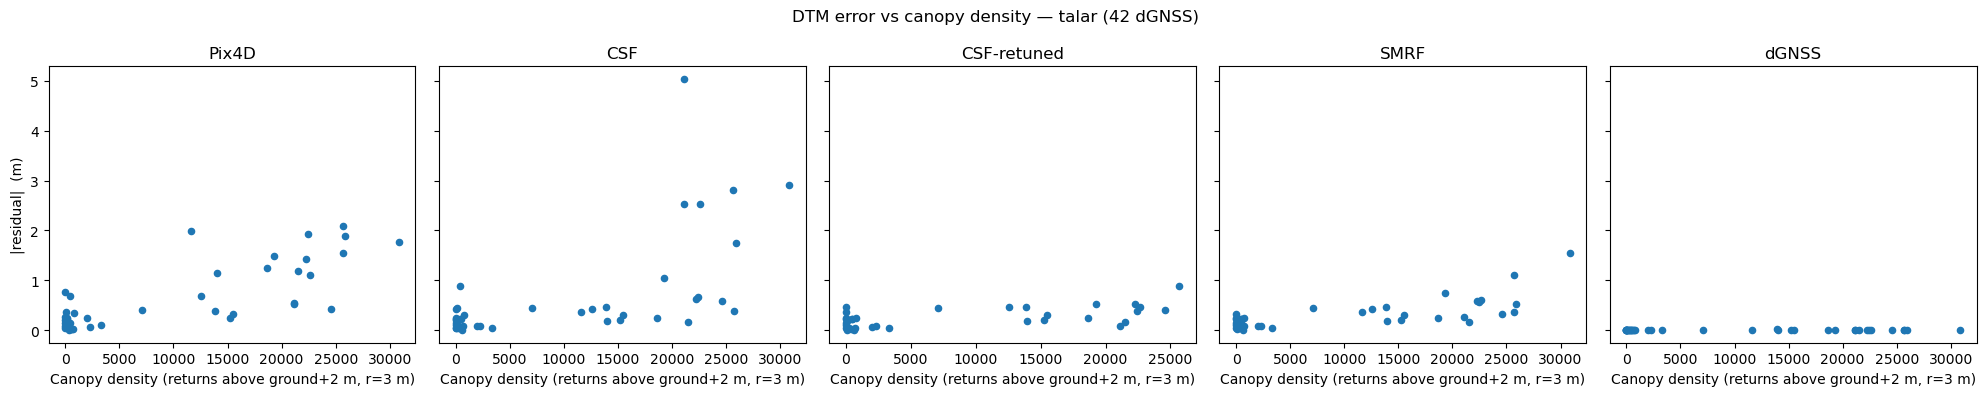

In [8]:
fig, axes = plt.subplots(1, len(samples), figsize=(4 * len(samples), 4), sharey=True)
if len(samples) == 1:
    axes = [axes]
ref = puntos["Elevation"].to_numpy(dtype=float)
for ax, (label, pred) in zip(axes, samples.items()):
    resid = np.abs(pred - ref)
    ax.scatter(puntos["canopy_density"], resid, s=20)
    ax.set_xlabel("Canopy density (returns above ground+2 m, r=3 m)")
    ax.set_title(f"{label}")
axes[0].set_ylabel("|residual|  (m)")
fig.suptitle("DTM error vs canopy density — talar (42 dGNSS)")
fig.tight_layout()
fig.savefig(FIGS / "density_vs_residual.png", dpi=150)
fig.show()

C:\Users\paco_\AppData\Local\Temp\claude\ipykernel_17816\59019116.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


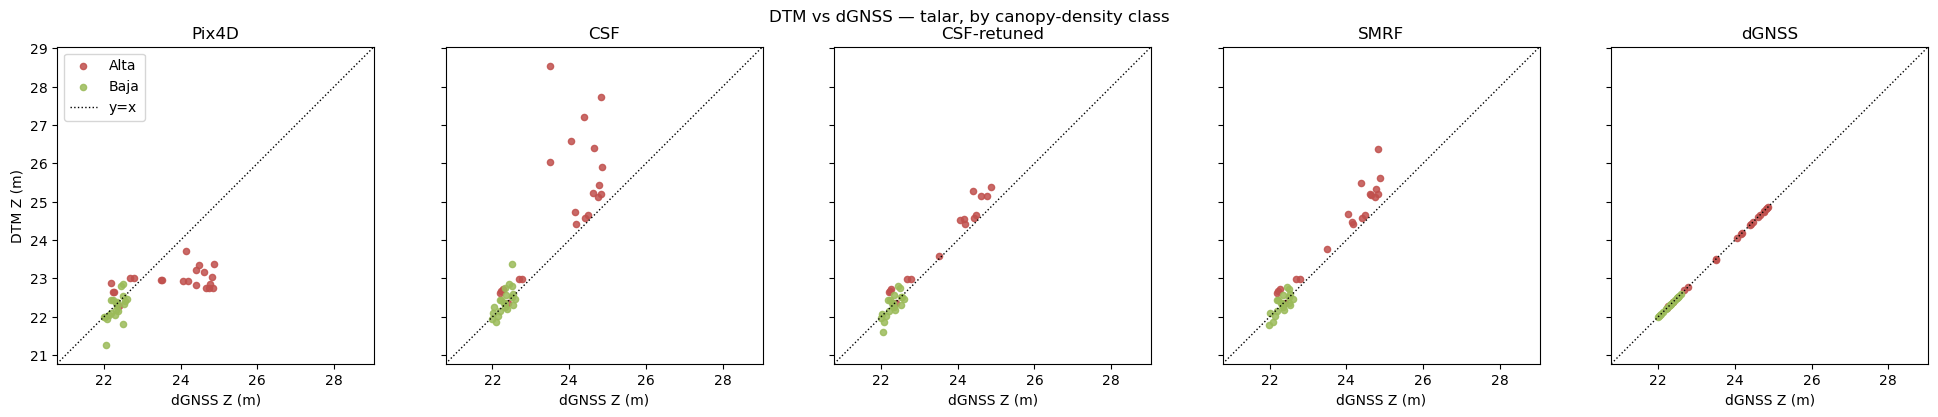

In [9]:
fig, axes = plt.subplots(1, len(samples), figsize=(4 * len(samples), 4), sharex=True, sharey=True)
if len(samples) == 1:
    axes = [axes]
lo = min(ref.min(), min(np.nanmin(p) for p in samples.values())) - 0.5
hi = max(ref.max(), max(np.nanmax(p) for p in samples.values())) + 0.5
for ax, (label, pred) in zip(axes, samples.items()):
    for cls, color in [("Alta", "#c0504d"), ("Baja", "#9bbb59")]:
        mask = (puntos["density_class"] == cls).to_numpy()
        ax.scatter(ref[mask], pred[mask], label=cls, s=20, color=color, alpha=0.85)
    ax.plot([lo, hi], [lo, hi], "k:", lw=1, label="y=x")
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel("dGNSS Z (m)")
    ax.set_title(label)
    ax.set_aspect("equal", "box")
    # ax.vlines(x=25, ymin=0, ymax=hi)
axes[0].set_ylabel("DTM Z (m)")
axes[0].legend()
fig.suptitle("DTM vs dGNSS — talar, by canopy-density class")
fig.tight_layout()
fig.savefig(FIGS / "dtm_vs_dgnss_scatter.png", dpi=150)
fig.show()

In [10]:
# Persist the summary tables for downstream notebooks / the report.
coverage.to_csv(OUT / "validation_coverage.csv")
summary.to_csv(OUT / "validation_summary.csv")
head_to_head.to_csv(OUT / "validation_head_to_head.csv")
stratified.to_csv(OUT / "validation_stratified.csv")
puntos.drop(columns="geometry").to_csv(OUT / "dgnss_with_density.csv", index=False)
print("Wrote:")
for name in ["validation_coverage.csv", "validation_summary.csv",
             "validation_head_to_head.csv", "validation_stratified.csv",
             "dgnss_with_density.csv"]:
    print(f"  {OUT / name}")

Wrote:
  C:\Users\paco_\OneDrive\Escritorio\repos\drone_reserve\outputs\02_dtm\validation_coverage.csv
  C:\Users\paco_\OneDrive\Escritorio\repos\drone_reserve\outputs\02_dtm\validation_summary.csv
  C:\Users\paco_\OneDrive\Escritorio\repos\drone_reserve\outputs\02_dtm\validation_head_to_head.csv
  C:\Users\paco_\OneDrive\Escritorio\repos\drone_reserve\outputs\02_dtm\validation_stratified.csv
  C:\Users\paco_\OneDrive\Escritorio\repos\drone_reserve\outputs\02_dtm\dgnss_with_density.csv


## Findings

- **Pix4D row reproduces the poster** to 2 dp on MAE/RMSE (0.636 / 0.904 vs 0.64 / 0.90).
  R² differs because the poster used Pearson² (r²); we report the coefficient of
  determination, the standard for accuracy assessment. On the near-flat Baja subset R²
  is unstable (tiny variance denominator) — trust RMSE/MAE/ME there.
- **SMRF more than halves Pix4D's error** (RMSE 0.90 → 0.43 m overall; 1.25 → 0.58 m
  dense), reframing the poster's "you need dGNSS in dense forest" conclusion.
- **Stock CSF was mis-tuned** (+1.1 m dense-canopy bias; the cloth hangs on low
  vegetation). The flat-floodplain retune (rigid + coarse cloth, tight threshold) flips
  it: on the **common valid subset** it edges out SMRF (Full RMSE 0.31 vs 0.35; dense
  0.41 vs 0.49) — but at the cost of **coverage** (36/42 vs 40/42 control points; ~9%
  fewer valid pixels), with the lost points concentrated in dense canopy. So it is more
  accurate *where it has ground* but leaves more gaps to interpolate.
- **dGNSS-DTM is excluded from accuracy claims** — interpolated from these same points,
  so its ~0 error is circular. Context only.
- **Decision (feeds step 03):** carry **both SMRF and retuned-CSF** into the step-03
  dGNSS bias-correction; leave-one-out CV picks the final production DTM. Bias-correction
  may close the small accuracy gap, in which case SMRF's better coverage wins.
- The continuous density figure is the genuinely new contribution: it shows where
  photogrammetry stops being trustworthy, without a hand-drawn polygon.